In [1]:
import sys
import os
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
import pytorch_lightning as pl

# Add src to path so we can import modules
sys.path.append(os.path.abspath('..'))

from loading.LightningGraphLoader import load_datasets
from models.MyModel import MyModel
from loading.DatasetInfo import DatasetInfo

/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.chdir("../..")
os.getcwd()

'/Users/williserdman/Documents/school/spring2026/db4ai/db4ai'

In [3]:
ds_name = "ENGB"
data = load_datasets([ds_name])[ds_name]

dl = data.data.train_dataloader()
graph_data = dl.dataset[0]
# graph_data should be the Data object provided to LightningNodeData
print(f"Loaded graph with {len(graph_data.x[0])} nodes and {len(graph_data.edge_index[1])} edges.")

Data(x=[7126, 3170], edge_index=[2, 35324], y=[7126], train_mask=[7126], val_mask=[7126], test_mask=[7126])
Loaded graph with 3170 nodes and 35324 edges.


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "
/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)
/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/src/loading

In [4]:
checkpoint_path = "optuna_logs/best_params/version_2/checkpoints/epoch=529-step=530.ckpt" # Cora
# checkpoint_path = "optuna_logs/best_params/version_1/checkpoints/epoch=580-step=581.ckpt" # squirrel

# Load the model
try:
    model = MyModel.load_from_checkpoint(checkpoint_path)
    model.eval()
    print("Model loaded successfully")
except Exception as e:
    print(f"Failed to load model: {e}")
    # Fallback or debugging hints
    print("Ensure that hparams.yaml contains valid ds_info and that the class is importable.")

Model loaded successfully


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/src/models/MyModel.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.cse = nn.CrossEntropyLoss(torch.tensor(ds_info.class_weights))


In [5]:
os.getcwd()

'/Users/williserdman/Documents/school/spring2026/db4ai/db4ai'

In [6]:
# Run the model on the full graph
with torch.no_grad():
    # Model expects 'data' object with .x and .edge_index
    logits, _ = model(graph_data)
    probs = torch.softmax(logits, dim=1)
    predictions = logits.argmax(dim=1)

# Calculate accuracy
# Assuming y is the ground truth labels
ground_truth = graph_data.y
# accuracy per node
correct_predictions = (predictions == ground_truth)
accuracy_per_node = correct_predictions.float()

print(f"Overall Accuracy: {accuracy_per_node.mean().item():.4f}")

# You can inspect specific nodes
print(f"First 10 nodes correct? {correct_predictions[:10].tolist()}")

train_mask = graph_data.train_mask
val_mask = graph_data.val_mask
test_mask = graph_data.test_mask


# Calculate accuracy per split
train_accuracy = accuracy_per_node[train_mask].mean().item()
val_accuracy = accuracy_per_node[val_mask].mean().item()
test_accuracy = accuracy_per_node[test_mask].mean().item()

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Val Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Overall Accuracy: 0.7241
First 10 nodes correct? [False, False, True, False, True, False, True, False, True, False]
Train Accuracy: 0.7209
Val Accuracy: 0.7263
Test Accuracy: 0.7314


Computing layout (this may take a moment)...
Drawing graph...


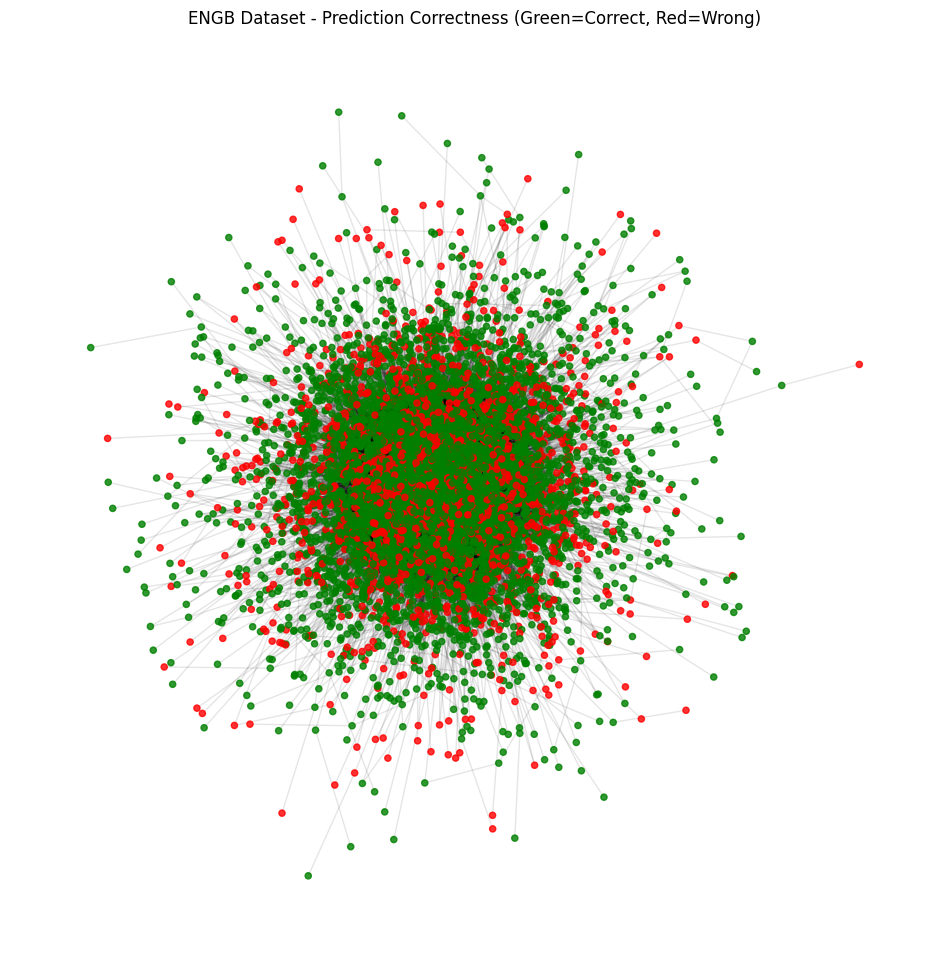

In [7]:
# Visualization
# Convert PyG data to NetworkX graph
G = to_networkx(graph_data, to_undirected=True)

# Define node colors based on correctness
# Green for correct, Red for incorrect
node_colors = ['green' if correct else 'red' for correct in correct_predictions.tolist()]

plt.figure(figsize=(12, 12))
print("Computing layout (this may take a moment)...")
# Use spring layout
pos = nx.spring_layout(G, k=0.1, iterations=50) # Reduced iterations for speed

node_edge_colors = []
for i in range(len(G.nodes)):
    if train_mask[i]:
        node_edge_colors.append('black')
    else:
        node_edge_colors.append('blue')

print("Drawing graph...")
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=node_colors, alpha=0.8,) # edgecolors=node_edge_colors)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title(f"{ds_name} Dataset - Prediction Correctness (Green=Correct, Red=Wrong)")
plt.axis('off')
plt.show()

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_2554/3948254421.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_classes)


Drawing graph with class label colors...


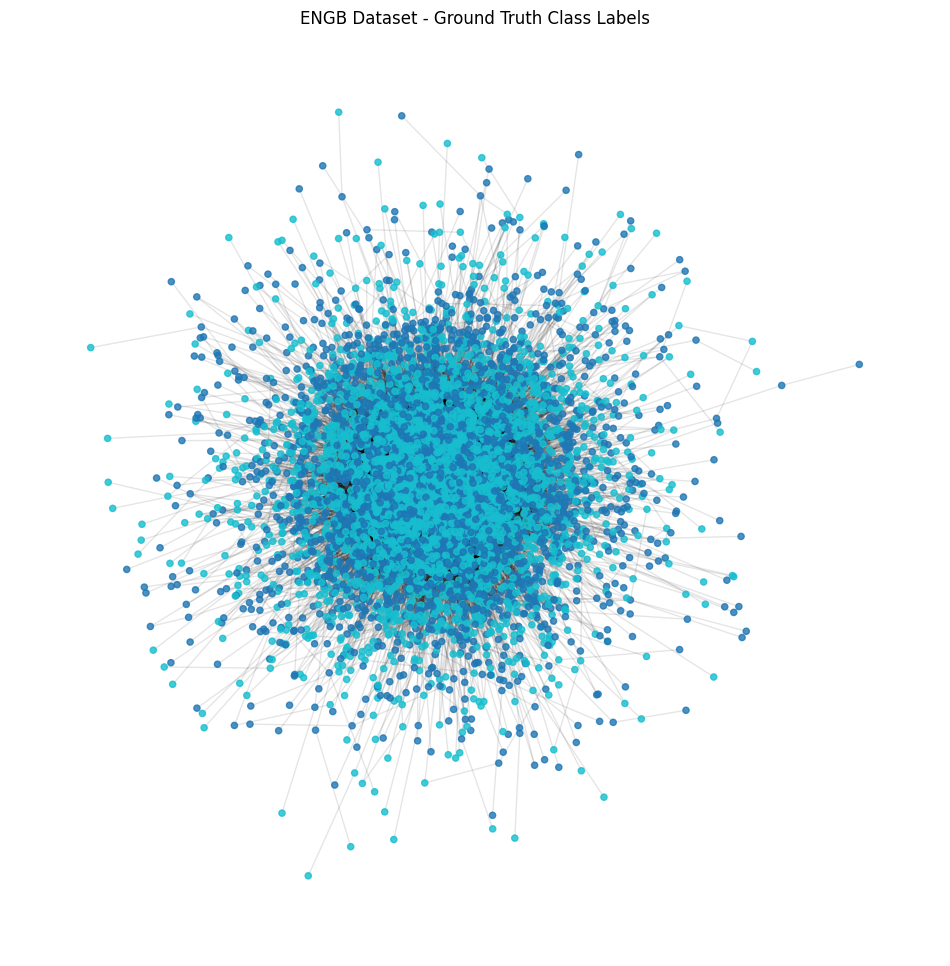

In [8]:
import numpy as np

# Visualize the Cora graph with node colors based on ground truth class labels

# Assign a color to each class label
import matplotlib.cm as cm

num_classes = len(torch.unique(ground_truth))
cmap = cm.get_cmap('tab10', num_classes)
class_colors = [cmap(label.item()) for label in ground_truth]

plt.figure(figsize=(12, 12))
print("Drawing graph with class label colors...")
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=class_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title(f"{ds_name} Dataset - Ground Truth Class Labels")
plt.axis('off')
plt.show()

Original graph: 7126 nodes, 35324 edges
Subgraph (All Correct Nodes): 5160 nodes, 18715 edges


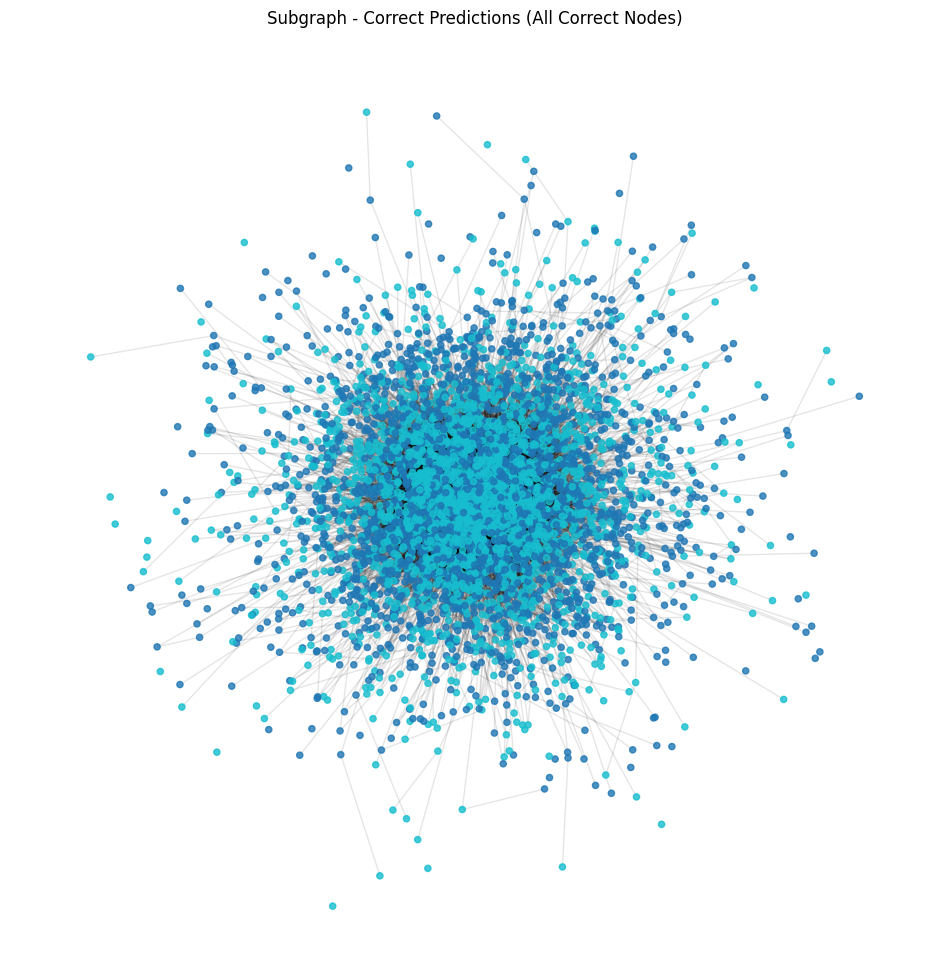

In [9]:
# Flag to filter for training nodes only
TRAINING_NODES = False
TRAIN_AND_VAL = False

# Create a mask for nodes to include
if TRAINING_NODES:
    # Intersection: Correctly predicted AND in training set
    subset_mask = correct_predictions & train_mask
    title_suffix = " (Training Nodes Only)"
elif TRAIN_AND_VAL:
    subset_mask = correct_predictions & (train_mask | val_mask)
    title_suffix = " (Training and Validation Nodes)"
else:
    # Just correctly predicted nodes
    subset_mask = correct_predictions
    title_suffix = " (All Correct Nodes)"

subset_indices = torch.where(subset_mask)[0].tolist()
subgraph = G.subgraph(subset_indices).copy()

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Subgraph{title_suffix}: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

# Visualize the subgraph
plt.figure(figsize=(12, 12))
pos_subgraph = {node: pos[node] for node in subgraph.nodes()}
# Use the same colors as the original graph (by node index)
subgraph_colors = [class_colors[node] for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos_subgraph, node_size=20, node_color=subgraph_colors, alpha=0.8)
nx.draw_networkx_edges(subgraph, pos_subgraph, alpha=0.1)

plt.title(f"Subgraph - Correct Predictions{title_suffix}")
plt.axis('off')
plt.show()

Subgraph (Training and Validation Nodes): 1583 nodes, 1818 edges


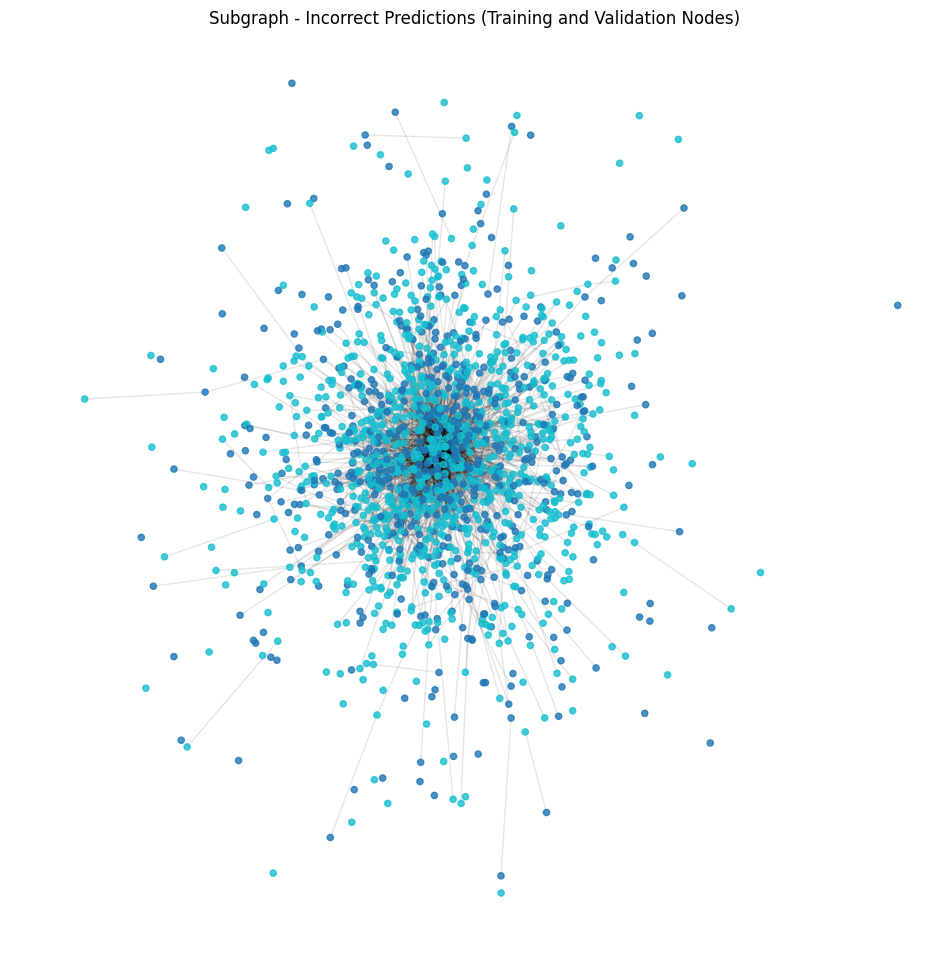

In [10]:
# Flag to filter for training nodes only
TRAINING_NODES = False
TRAIN_AND_VAL = True

# Create a mask for nodes to include
if TRAINING_NODES:
    # Intersection: Correctly predicted AND in training set
    subset_mask = (correct_predictions==0) & train_mask
    title_suffix = " (Training Nodes Only)"
elif TRAIN_AND_VAL:
    subset_mask = (correct_predictions==0) & (train_mask | val_mask)
    title_suffix = " (Training and Validation Nodes)"
else:
    # Just correctly predicted nodes
    subset_mask = correct_predictions
    title_suffix = " (All Correct Nodes)"

subset_indices = torch.where(subset_mask)[0].tolist()
subgraph = G.subgraph(subset_indices).copy()

print(f"Subgraph{title_suffix}: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

# Visualize the subgraph
plt.figure(figsize=(12, 12))
pos_subgraph = {node: pos[node] for node in subgraph.nodes()}
# Use the same colors as the original graph (by node index)
subgraph_colors = [class_colors[node] for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos_subgraph, node_size=20, node_color=subgraph_colors, alpha=0.8)
nx.draw_networkx_edges(subgraph, pos_subgraph, alpha=0.1)

plt.title(f"Subgraph - Incorrect Predictions{title_suffix}")
plt.axis('off')
plt.show()

Edges: Correct-Correct: 18715, Incorrect-Incorrect: 2719, Mixed: 13890


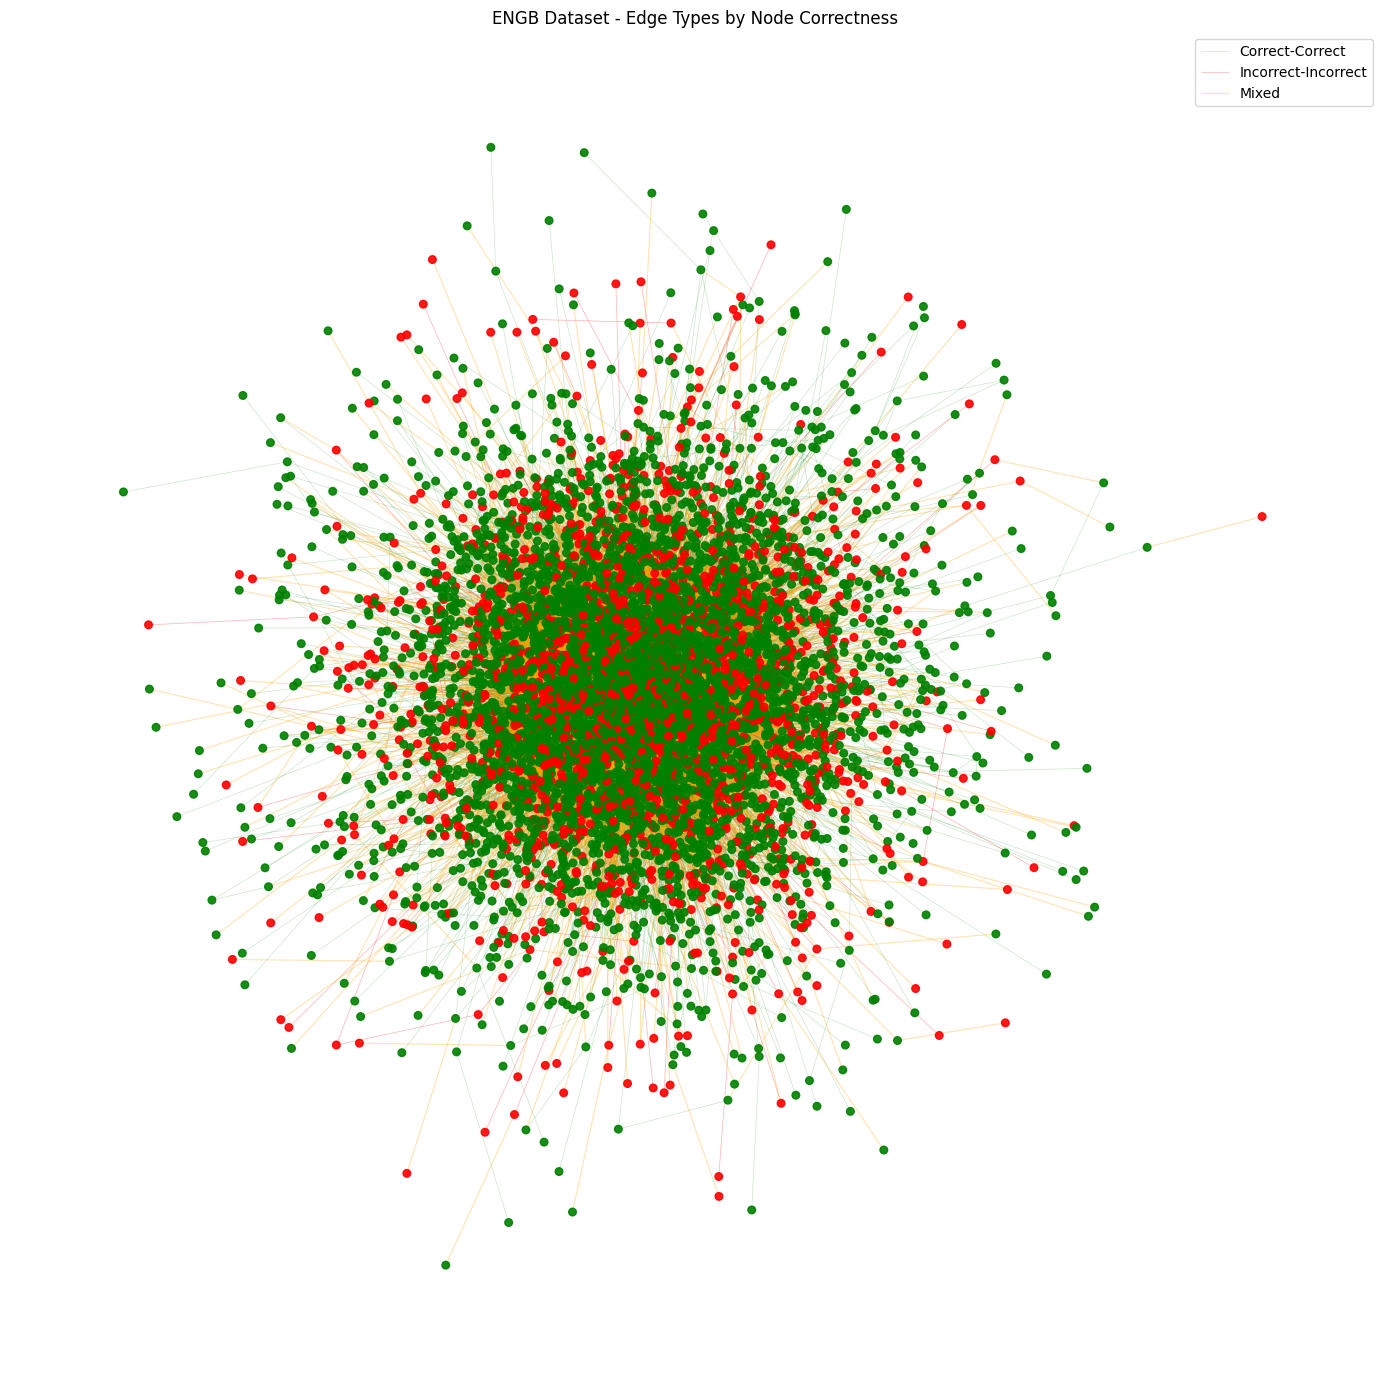


Edge Distribution:
Correct-Correct: 52.98%
Incorrect-Incorrect: 7.70%
Mixed (boundary): 39.32%


In [11]:
# Create a graph with edges colored based on whether they connect correct/incorrect nodes
fig, ax = plt.subplots(figsize=(14, 14))

# Separate edges into three categories
correct_to_correct = []
incorrect_to_incorrect = []
mixed_edges = []

for edge in G.edges():
    node1, node2 = edge
    node1_correct = correct_predictions[node1].item()
    node2_correct = correct_predictions[node2].item()
    
    if node1_correct and node2_correct:
        correct_to_correct.append(edge)
    elif not node1_correct and not node2_correct:
        incorrect_to_incorrect.append(edge)
    else:
        mixed_edges.append(edge)

print(f"Edges: Correct-Correct: {len(correct_to_correct)}, "
      f"Incorrect-Incorrect: {len(incorrect_to_incorrect)}, "
      f"Mixed: {len(mixed_edges)}")

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, alpha=0.9)

# Draw edges with different colors
nx.draw_networkx_edges(G, pos, edgelist=correct_to_correct, 
                       edge_color='green', alpha=0.2, width=0.5, label='Correct-Correct')
nx.draw_networkx_edges(G, pos, edgelist=incorrect_to_incorrect, 
                       edge_color='red', alpha=0.3, width=0.5, label='Incorrect-Incorrect')
nx.draw_networkx_edges(G, pos, edgelist=mixed_edges, 
                       edge_color='orange', alpha=0.3, width=0.8, label='Mixed')

plt.title(f"{ds_name} Dataset - Edge Types by Node Correctness")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
total_edges = G.number_of_edges()
print(f"\nEdge Distribution:")
print(f"Correct-Correct: {len(correct_to_correct)/total_edges:.2%}")
print(f"Incorrect-Incorrect: {len(incorrect_to_incorrect)/total_edges:.2%}")
print(f"Mixed (boundary): {len(mixed_edges)/total_edges:.2%}")

In [12]:
# Print the test mask
print("Test mask:")
print(test_mask.tolist())

# Get indices of nodes in the test set that were correctly predicted
test_correct_indices = torch.where(test_mask & correct_predictions)[0].tolist()
print(f"\nIndices of correctly predicted nodes in test set:")
print(test_correct_indices)
print(f"Number of correct predictions in test set: {len(test_correct_indices)}")

Test mask:
[True, False, False, False, False, False, False, True, True, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, True, False, True, False, False, False, False, False, True, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, False,

In [13]:
#####################
###   GAE CONFIG  ###
#####################

ALL_CORRECT_NODES = True
CORRECT_WITH_VAL = False
ALL_NODES = False

Correctly predicted nodes subgraph: 5160 nodes, 18715 edges
Largest connected component: 4779 nodes, 18688 edges


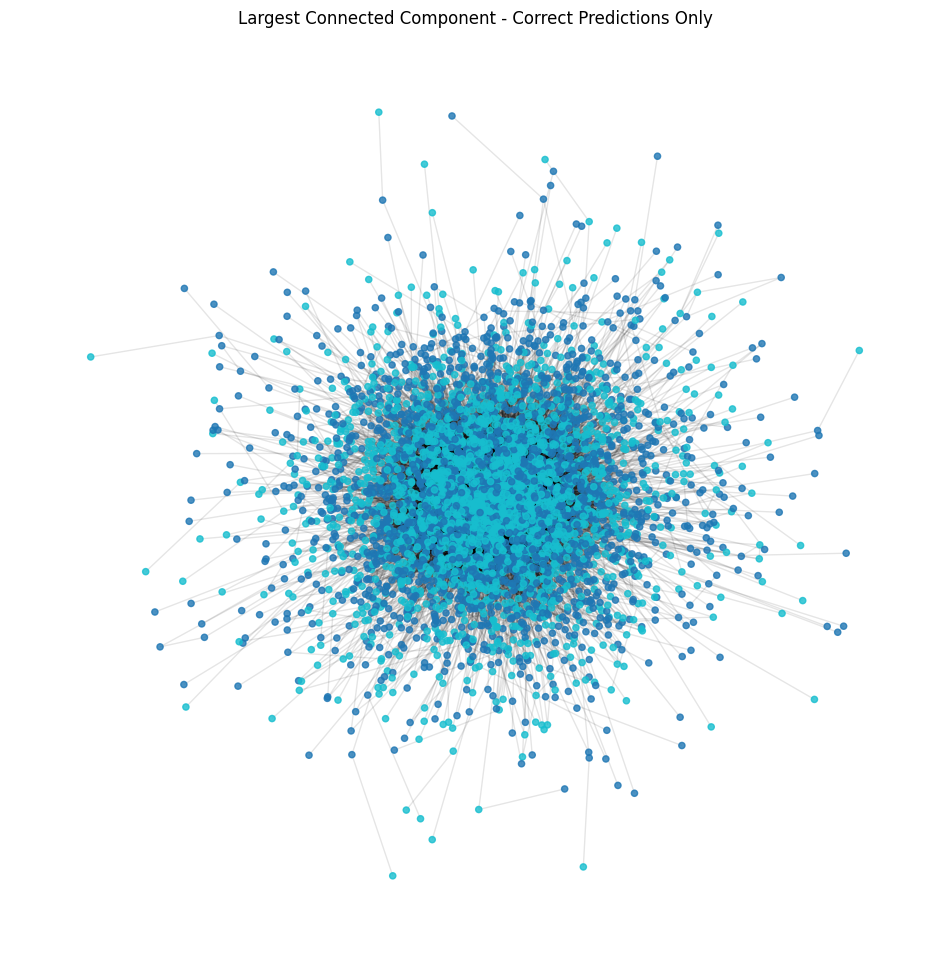

In [14]:
from torch_geometric.utils import to_undirected

# Get subgraph of only correctly predicted nodes
correct_node_indices = torch.where(correct_predictions)[0].tolist()
subgraph_correct = G.subgraph(correct_node_indices).copy()

# Find the largest connected component
largest_cc = max(nx.connected_components(subgraph_correct), key=len)
largest_cc_subgraph = subgraph_correct.subgraph(largest_cc).copy()

print(f"Correctly predicted nodes subgraph: {subgraph_correct.number_of_nodes()} nodes, {subgraph_correct.number_of_edges()} edges")
print(f"Largest connected component: {largest_cc_subgraph.number_of_nodes()} nodes, {largest_cc_subgraph.number_of_edges()} edges")

# Visualize the largest component
plt.figure(figsize=(12, 12))
pos_lcc = {node: pos[node] for node in largest_cc_subgraph.nodes()}
lcc_colors = [class_colors[node] for node in largest_cc_subgraph.nodes()]

nx.draw_networkx_nodes(largest_cc_subgraph, pos_lcc, node_size=20, node_color=lcc_colors, alpha=0.8)
nx.draw_networkx_edges(largest_cc_subgraph, pos_lcc, alpha=0.1)

plt.title(f"Largest Connected Component - Correct Predictions Only")
plt.axis('off')
plt.show()

In [15]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch_geometric.nn as gnn
from torch_geometric.utils import subgraph

subset_mask = correct_predictions # just using the correct prediction mask
subset_indices = torch.tensor(list(largest_cc)) # use indices from largest connected component

edge_index_correct, _ = subgraph(subset_indices, graph_data.edge_index, relabel_nodes=True)
x_correct = graph_data.x[subset_indices] # get corresponding features

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCNEncoder, self).__init__()
        self.conv1 = gnn.GCNConv(in_channels, hidden_channels)
        self.conv2 = gnn.GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)


in_channels = graph_data.num_node_features
hidden_channels = 128
out_channels = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gae = gnn.GAE(GCNEncoder(in_channels, hidden_channels, out_channels)).to(device)
optimizer = torch.optim.Adam(model_gae.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)

x_correct = x_correct.to(device)
edge_index_correct = edge_index_correct.to(device)


model_gae.train()
for epoch in range(1, 4001):
    optimizer.zero_grad()
    z = model_gae.encode(x_correct, edge_index_correct)
    loss = model_gae.recon_loss(z, edge_index_correct)
    loss.backward()
    optimizer.step()
    
    scheduler.step(loss)
    
    if epoch % 50 == 0:
        print(f'Epoch: {epoch:04d}, Loss: {loss.item():.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

print("GAE Training Complete.")


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:1340: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch: 0050, Loss: 1.1357, LR: 0.010000
Epoch: 0100, Loss: 1.0776, LR: 0.010000
Epoch: 0150, Loss: 1.0057, LR: 0.010000
Epoch: 0200, Loss: 0.9883, LR: 0.010000
Epoch: 0250, Loss: 0.9605, LR: 0.010000
Epoch: 0300, Loss: 0.9346, LR: 0.010000
Epoch: 0350, Loss: 0.9156, LR: 0.010000
Epoch: 0400, Loss: 0.9072, LR: 0.010000
Epoch: 0450, Loss: 0.8920, LR: 0.010000
Epoch: 0500, Loss: 0.8874, LR: 0.010000
Epoch: 0550, Loss: 0.8768, LR: 0.010000
Epoch: 0600, Loss: 0.8667, LR: 0.010000
Epoch: 0650, Loss: 0.8671, LR: 0.010000
Epoch: 0700, Loss: 0.8531, LR: 0.010000
Epoch: 0750, Loss: 0.8535, LR: 0.010000
Epoch: 0800, Loss: 0.8446, LR: 0.010000
Epoch: 0850, Loss: 0.8444, LR: 0.010000
Epoch: 0900, Loss: 0.8430, LR: 0.010000
Epoch: 0950, Loss: 0.8360, LR: 0.010000
Epoch: 1000, Loss: 0.8371, LR: 0.010000
Epoch: 1050, Loss: 0.8337, LR: 0.010000
Epoch: 1100, Loss: 0.8293, LR: 0.010000
Epoch: 1150, Loss: 0.8255, LR: 0.010000
Epoch: 1200, Loss: 0.8264, LR: 0.010000
Epoch: 1250, Loss: 0.8328, LR: 0.010000


In [16]:
if CORRECT_WITH_VAL:
    subset_mask = correct_predictions # just using the correct prediction mask for new
    subset_indices = torch.where(subset_mask)[0] # getting the indices

    # select 80% of the correct prediction indices, other 20% dropped essentially validation for reconstruction loss
    num_to_keep = int(len(subset_indices) * 0.8)
    random_indices = torch.randperm(len(subset_indices))[:num_to_keep]
    subset_indices = subset_indices[random_indices]

    edge_index_correct, _ = subgraph(subset_indices, graph_data.edge_index, relabel_nodes=True) # create a subgraph from the most (not necessarily a component)
    x_correct = graph_data.x[subset_indices] # get corresponding features

    class GCNEncoder(torch.nn.Module):
        def __init__(self, in_channels, hidden_channels, out_channels):
            super(GCNEncoder, self).__init__()
            self.conv1 = gnn.GCNConv(in_channels, hidden_channels)
            self.conv2 = gnn.GCNConv(hidden_channels, out_channels)

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index).relu()
            return self.conv2(x, edge_index)


    in_channels = graph_data.num_node_features
    hidden_channels = 128
    out_channels = 64

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_gae = gnn.GAE(GCNEncoder(in_channels, hidden_channels, out_channels)).to(device)
    optimizer = torch.optim.Adam(model_gae.parameters(), lr=0.01)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)

    x_correct = x_correct.to(device)
    edge_index_correct = edge_index_correct.to(device)


    model_gae.train()
    for epoch in range(1, 4001):
        optimizer.zero_grad()
        z = model_gae.encode(x_correct, edge_index_correct)
        loss = model_gae.recon_loss(z, edge_index_correct)
        loss.backward()
        optimizer.step()
        
        scheduler.step(loss)
        
        if epoch % 50 == 0:
            print(f'Epoch: {epoch:04d}, Loss: {loss.item():.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

    print("GAE Training Complete.")


In [17]:
if ALL_NODES:
    subset_mask = correct_predictions # just using the correct prediction mask for new
    subset_indices = torch.where(subset_mask)[0] # getting the indices

    # select 80% of the correct prediction indices, other 20% dropped essentially validation for reconstruction loss
    num_to_keep = int(len(subset_indices) * 0.8)
    random_indices = torch.randperm(len(subset_indices))[:num_to_keep]
    subset_indices = subset_indices[random_indices]

    edge_index_correct = graph_data.edge_index
    x_correct = graph_data.x

    class GCNEncoder(torch.nn.Module):
        def __init__(self, in_channels, hidden_channels, out_channels):
            super(GCNEncoder, self).__init__()
            self.conv1 = gnn.GCNConv(in_channels, hidden_channels)
            self.conv2 = gnn.GCNConv(hidden_channels, out_channels)

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index).relu()
            return self.conv2(x, edge_index)


    in_channels = graph_data.num_node_features
    hidden_channels = 128
    out_channels = 64

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_gae = gnn.GAE(GCNEncoder(in_channels, hidden_channels, out_channels)).to(device)
    optimizer = torch.optim.Adam(model_gae.parameters(), lr=0.01)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=200)

    x_correct = x_correct.to(device)
    edge_index_correct = edge_index_correct.to(device)


    model_gae.train()
    for epoch in range(1, 4001):
        optimizer.zero_grad()
        z = model_gae.encode(x_correct, edge_index_correct)
        loss = model_gae.recon_loss(z, edge_index_correct)
        loss.backward()
        optimizer.step()
        
        scheduler.step(loss)
        
        if epoch % 50 == 0:
            print(f'Epoch: {epoch:04d}, Loss: {loss.item():.4f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

    print("GAE Training Complete.")


In [18]:
from torch_geometric.utils import degree

correct_node_indices = torch.where(correct_predictions)[0] # from our GAT again
incorrect_node_indices = torch.where(~correct_predictions)[0]

model_gae.eval()
with torch.no_grad():
    z = model_gae.encode(graph_data.x.to(device), graph_data.edge_index.to(device)) # for our entire graph now
    
    # edge probabilities: sigmoid(z_i * z_j)
    # between 0 and 1 for every actual edge in edge_index
    edge_probs = model_gae.decoder(z, graph_data.edge_index.to(device), sigmoid=True)
    
    # We sum the probabilities of all edges connected to a node and divide by degree
    node_error_sum = torch.zeros(graph_data.num_nodes).to(device)
    node_error_sum.scatter_add_(0, graph_data.edge_index[0].to(device), edge_probs) # for all sources indices += edge_prob
    
    node_degree = degree(graph_data.edge_index[0], num_nodes=graph_data.num_nodes).to(device) # degree of each node, possibly duplicated
    node_avg_confidence = node_error_sum / (node_degree + 1e-6) # average confidence per node (per edge)

node_avg_confidence = node_avg_confidence.cpu().numpy()
correct_mask_np = correct_predictions.cpu().numpy()

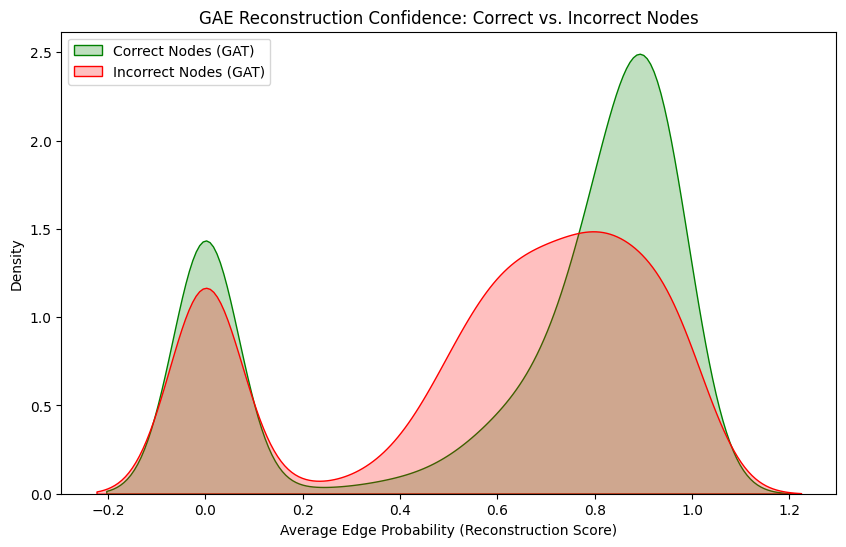

Mean Confidence (Correct): 0.6252
Mean Confidence (Incorrect): 0.5736


In [19]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot distribution for Correct Nodes
sns.kdeplot(node_avg_confidence[correct_mask_np], # type: ignore
            label='Correct Nodes (GAT)', fill=True, color='green')

# Plot distribution for Incorrect Nodes
sns.kdeplot(node_avg_confidence[~correct_mask_np], # type: ignore
            label='Incorrect Nodes (GAT)', fill=True, color='red')

plt.title("GAE Reconstruction Confidence: Correct vs. Incorrect Nodes")
plt.xlabel("Average Edge Probability (Reconstruction Score)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Print mean scores
print(f"Mean Confidence (Correct): {node_avg_confidence[correct_mask_np].mean():.4f}")
print(f"Mean Confidence (Incorrect): {node_avg_confidence[~correct_mask_np].mean():.4f}")

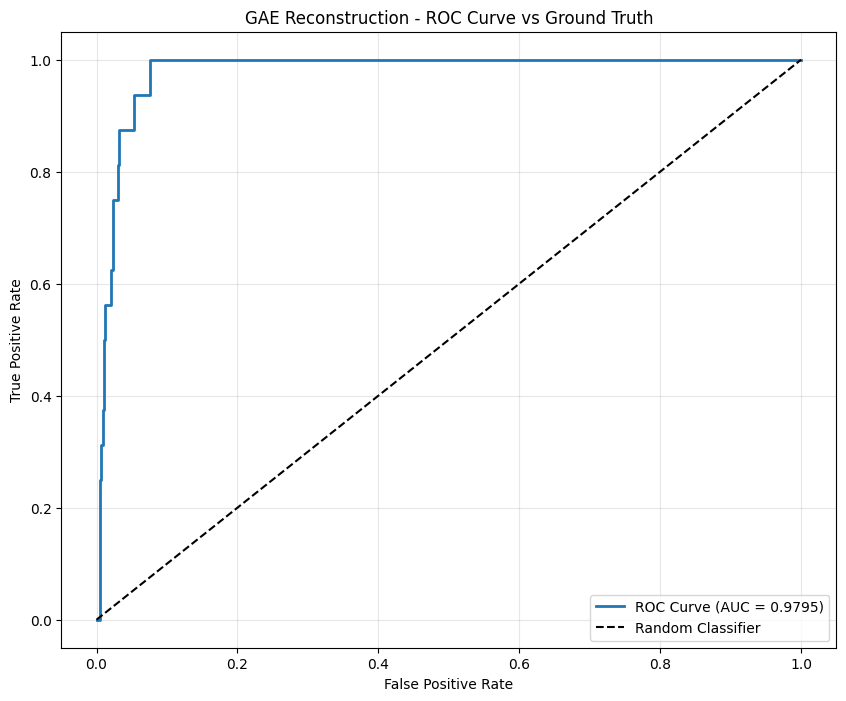

ROC AUC Score: 0.9795


In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

# Create a confusion matrix for GAE reconstruction performance

# Binarize the problem: edges that exist vs edges that don't exist
# Get all possible node pairs
all_node_pairs = []
for i in range(graph_data.num_nodes):
    for j in range(i+1, graph_data.num_nodes):
        all_node_pairs.append((i, j))

# Create a set of actual edges for fast lookup
actual_edges_set = set()
for i in range(graph_data.edge_index.shape[1]):
    u, v = graph_data.edge_index[0, i].item(), graph_data.edge_index[1, i].item()
    if u > v:
        u, v = v, u
    actual_edges_set.add((u, v))

# Get reconstruction probabilities for all pairs (sample if too large)
sample_size = min(10000, len(all_node_pairs))
sampled_pairs = np.random.choice(len(all_node_pairs), sample_size, replace=False)

true_labels = []
pred_probs = []

with torch.no_grad():
    z_all = model_gae.encode(graph_data.x.to(device), graph_data.edge_index.to(device))
    
    for idx in sampled_pairs:
        i, j = all_node_pairs[idx]
        # Reconstruction probability
        prob = torch.sigmoid(torch.dot(z_all[i], z_all[j])).item()
        pred_probs.append(prob)
        
        # Ground truth: does edge exist?
        true_labels.append(1.0 if (i, j) in actual_edges_set else 0.0)

pred_probs = np.array(pred_probs)
true_labels = np.array(true_labels)

# Plot ROC curve

fpr, tpr, _ = roc_curve(true_labels, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GAE Reconstruction - ROC Curve vs Ground Truth')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

In [28]:
from torch_geometric.utils import k_hop_subgraph, subgraph
import copy

k_hops = 1

# 1. Get k-hop neighbors of incorrect nodes
incorrect_nodes = torch.where(~correct_predictions)[0]
subset, _, _, _ = k_hop_subgraph(incorrect_nodes, num_hops=k_hops, edge_index=graph_data.edge_index)

print(f"Number of incorrect nodes: {len(incorrect_nodes)}")
print(f"Number of nodes in {k_hops}-hop neighborhood (including incorrect nodes): {len(subset)}")

# 2. Calculate reconstruction error for this group
model_gae.eval()
with torch.no_grad():
    # Extract the subgraph for the k-hop neighborhood
    edge_index_k_hop, _ = subgraph(subset, graph_data.edge_index, relabel_nodes=True)
    x_k_hop = graph_data.x[subset].to(device)
    
    # Encode to latent space
    z_k_hop = model_gae.encode(x_k_hop, edge_index_k_hop.to(device))
    
    # Calculate GAE reconstruction loss (binary cross entropy on edges)
    recon_loss = model_gae.recon_loss(z_k_hop, edge_index_k_hop.to(device))
    print(f"Edge Reconstruction Loss for the {k_hops}-hop neighborhood: {recon_loss.item():.4f}")

# 3. Predict using the reconstructed graph
with torch.no_grad():
    # Pass all features through GAE encoder
    z_all = model_gae.encode(graph_data.x.to(device), graph_data.edge_index.to(device))
    
    # Predict probabilities of existing edges
    edge_probs = model_gae.decoder(z_all, graph_data.edge_index.to(device), sigmoid=True)
    
    # Filter edges based on reconstruction confidence (e.g., threshold > 0.5)
    edge_mask = edge_probs > 0.5
    reconstructed_edges = graph_data.edge_index[:, edge_mask.cpu()]
    
    # Create new graph data with reconstructed edges
    graph_data_recon = copy.deepcopy(graph_data)
    graph_data_recon.edge_index = reconstructed_edges
    
    # Run the GNN model
    model.eval()
    logits_recon, _ = model(graph_data_recon)
    predictions_recon = logits_recon.argmax(dim=1)
    
    correct_predictions_recon = (predictions_recon == graph_data_recon.y)
    accuracy_recon = correct_predictions_recon.float()
    
    print(f"\n--- Prediction Results ---")
    print(f"Original Overall Accuracy: {accuracy_per_node.mean().item():.4f}")
    print(f"Reconstructed Graph Overall Accuracy: {accuracy_recon.mean().item():.4f}")
    print(f"Original edges: {graph_data.edge_index.size(1)}, Reconstructed edges: {reconstructed_edges.size(1)}")
    
    # Check if previously incorrect nodes improved
    incorrect_mask = ~correct_predictions
    now_correct = correct_predictions_recon[incorrect_mask].sum().item()
    print(f"Number of previously incorrect nodes that are now correct: {now_correct} out of {len(incorrect_nodes)}")

Number of incorrect nodes: 1966
Number of nodes in 1-hop neighborhood (including incorrect nodes): 4277
Edge Reconstruction Loss for the 1-hop neighborhood: 1.0506

--- Prediction Results ---
Original Overall Accuracy: 0.7241
Reconstructed Graph Overall Accuracy: 0.7224
Original edges: 35324, Reconstructed edges: 33740
Number of previously incorrect nodes that are now correct: 81 out of 1966
